# Exploratory Data Analysis - Heart Disease Dataset


Mục tiêu chính:
- Kiểm tra cấu trúc dữ liệu, missing values và duplicate records.
- Chuyển bài toán về binary classification: `0 = không bệnh`, `1 = có bệnh`.
- Phân tích phân phối biến số và biến phân loại theo target.
- Xuất hình ảnh/bảng tóm tắt vào thư mục `reports/` để dùng trong báo cáo.


In [ ]:
# Import Library for EDA
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style chung để biểu đồ nhất quán và dễ đọc trong báo cáo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Using Paired of Matplotlib for visualization
PAIRED_COLORS = plt.get_cmap("Paired").colors
TARGET_PALETTE = {0: PAIRED_COLORS[1], 1: PAIRED_COLORS[5]}
CATEGORY_PALETTE = list(PAIRED_COLORS)

# Define path
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "heart.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

# Creating folder if it not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Data path: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/data/raw/heart.csv
Figures will be saved to: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/reports/figures


## 1. Load Dataset

File `heart.csv` trong project không có header, vì vậy cần truyền danh sách tên cột thủ công. Các giá trị `?` được xem là missing values.

In [ ]:
# Cleveland Heart Disease Dataset include 13 features and 1 target
columns = [
    "age",       
    "sex",       # 1 = male, 0 = female
    "cp",        # Chest pain type
    "trestbps",  # Resting blood pressure
    "chol",      # Serum cholesterol
    "fbs",       # Fasting blood sugar > 120 mg/dl
    "restecg",   # Resting electrocardiographic results
    "thalach",   # Maximum heart rate achieved
    "exang",     # Exercise induced angina
    "oldpeak",   # ST depression induced by exercise
    "slope",     # Slope of peak exercise ST segment
    "ca",        # Number of major vessels colored by fluoroscopy
    "thal",      # Thalassemia status
    "target",    # Diagnosis: 0 = no disease, 1-4 = disease severity
]

# Read Dataset. Using names=columns cause file raw without header.
df_raw = pd.read_csv(DATA_PATH, names=columns, na_values="?")

# Keep raw data copy.
df = df_raw.copy()

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Dataset shape: 303 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Quality Check


In [ ]:
# Check data type and non-null by column
# If column => object => Symbol in dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
# Generating missing values tabl
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

# Check duplicate record by row
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")
display(missing_summary if not missing_summary.empty else "No missing values")

# Save missing table
missing_summary.to_csv(TABLES_DIR / "missing_values_summary.csv")

Duplicate rows: 0


,missing_count,missing_percent
ca,4,1.32
thal,2,0.66


In [ ]:
# Descriptive_statstictis
descriptive_stats = df.describe().T

display(descriptive_stats)
descriptive_stats.to_csv(TABLES_DIR / "descriptive_statistics.csv")

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Feature Groups and Missing Value Handling

In [ ]:
# Merge variable by type
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Impute missing values for categorical using mode.
# ca & thal is group id/category, using median not good.
for col in ["ca", "thal"]:
    mode_value = df[col].mode(dropna=True)[0]
    missing_before = df[col].isna().sum()
    df[col] = df[col].fillna(mode_value)
    print(f"{col}: filled {missing_before} missing values with mode = {mode_value}")

print("Missing values after imputation:")
display(df.isna().sum().to_frame("missing_count"))

ca: filled 4 missing values with mode = 0.0
thal: filled 2 missing values with mode = 3.0
Missing values after imputation:


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Convert categoracal to int
for col in categorical_features:
    df[col] = df[col].astype(int)

# Keep root target to comparation, then create binary target for classification.
df["target_original"] = df["target"].astype(int)
df["target"] = (df["target_original"] > 0).astype(int)

target_labels = {0: "No disease", 1: "Disease"}

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_original
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1,2
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0,0


## 4. Target Distribution

,target,count,label,percent
0,0,164,No disease,54.13
1,1,139,Disease,45.87


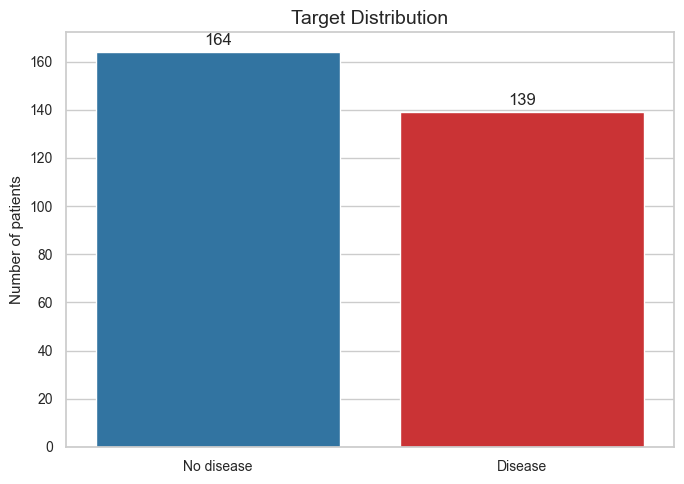

In [ ]:
# Distribution table target after binarization
target_summary = (
    df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)
target_summary["label"] = target_summary["target"].map(target_labels)
target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(2)

display(target_summary)
target_summary.to_csv(TABLES_DIR / "target_distribution.csv", index=False)

# Visualization
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=target_summary, x="label", y="count", hue="label", palette=[PAIRED_COLORS[1], PAIRED_COLORS[5]], legend=False, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_title("Target Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Numerical Feature Analysis

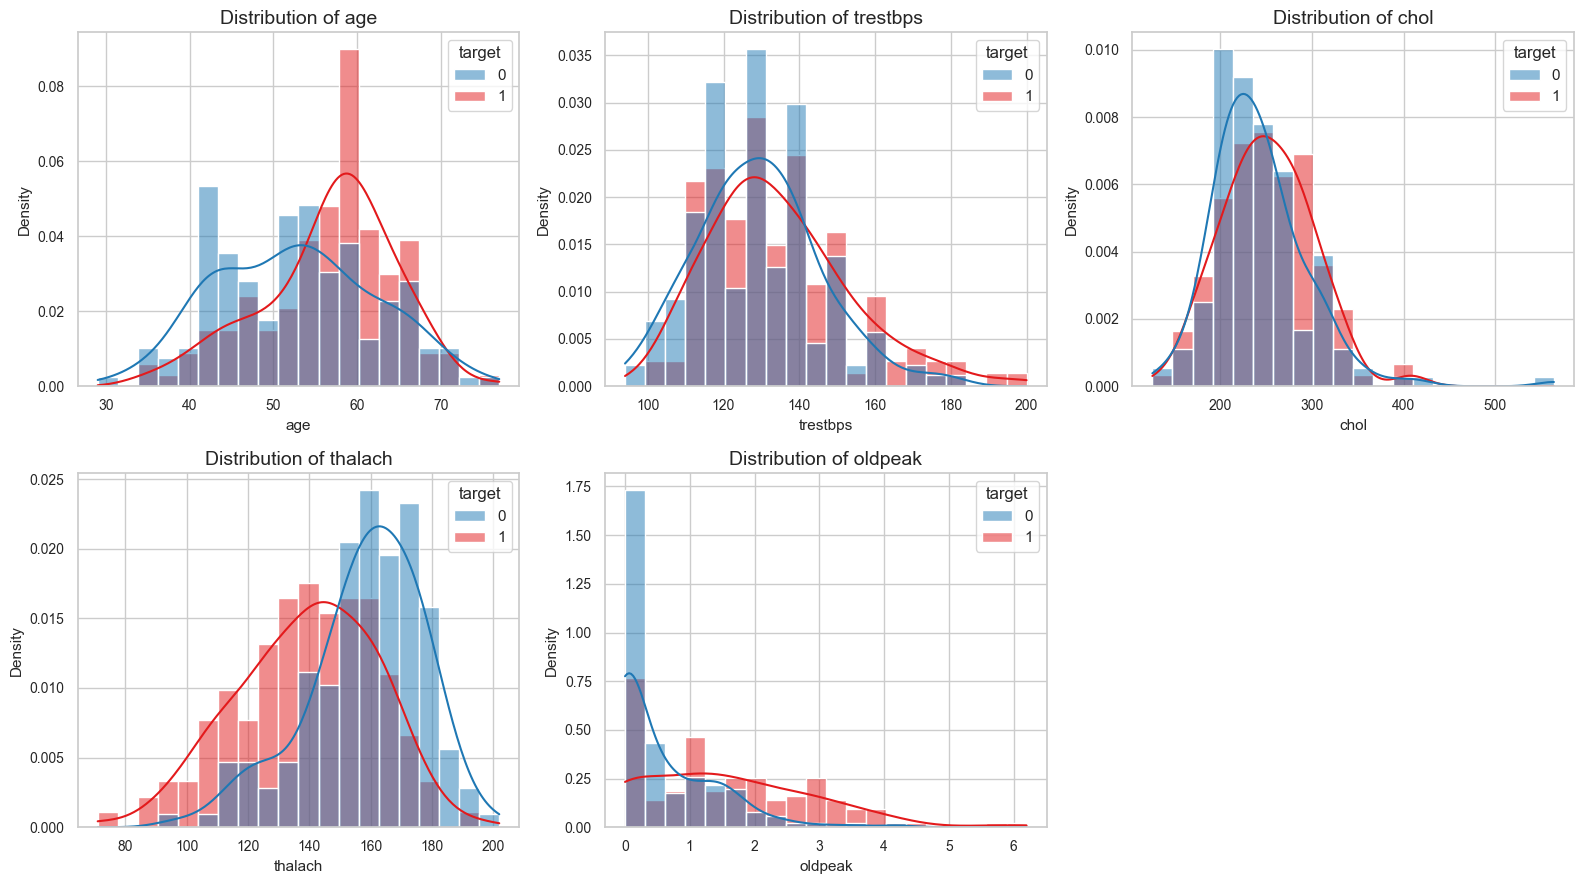

In [ ]:
# Histogram
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.histplot(
        data=df,
        x=col,
        hue="target",
        palette=TARGET_PALETTE,
        bins=20,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Hide mod subplot cause only 5 var
for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_distributions_by_target.png", dpi=300, bbox_inches="tight")
plt.show()

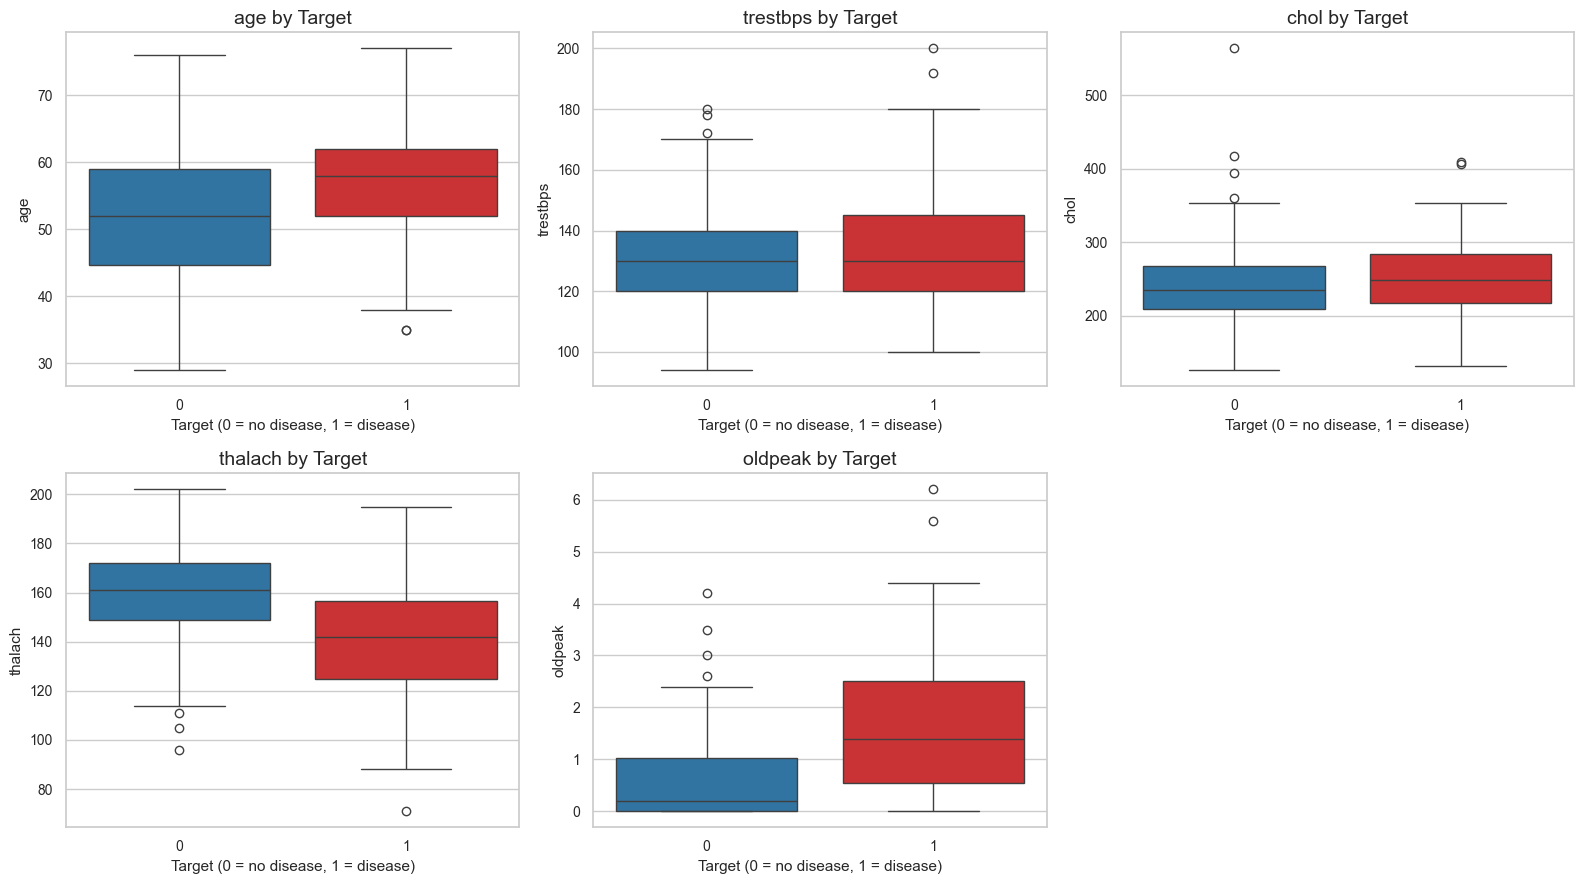

In [ ]:
# Boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df, x="target", y=col, hue="target", palette=TARGET_PALETTE, legend=False, ax=ax)
    ax.set_title(f"{col} by Target")
    ax.set_xlabel("Target (0 = no disease, 1 = disease)")
    ax.set_ylabel(col)

for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_boxplots_by_target.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Statistic table
numeric_by_target = df.groupby("target")[numeric_features].agg(["mean", "median", "std"]).round(2)

display(numeric_by_target)
numeric_by_target.to_csv(TABLES_DIR / "numeric_features_by_target.csv")

age              trestbps                  chol                \
         mean median   std     mean median    std    mean median    std   
target                                                                    
0       52.59   52.0  9.51   129.25  130.0  16.20  242.64  234.5  53.46   
1       56.63   58.0  7.94   134.57  130.0  18.77  251.47  249.0  49.49   

       thalach               oldpeak               
          mean median    std    mean median   std  
target                                             
0       158.38  161.0  19.20    0.59    0.2  0.78  
1       139.26  142.0  22.59    1.57    1.4  1.30

## 6. Categorical Feature Analysis

In [ ]:
# Calculate disease rate by category
category_rate_frames = []

for col in categorical_features:
    temp = (
        df.groupby(col)["target"]
        .agg(count="count", disease_rate="mean")
        .reset_index()
        .rename(columns={col: "category"})
    )
    temp["feature"] = col
    temp["disease_rate"] = (temp["disease_rate"] * 100).round(2)
    category_rate_frames.append(temp[["feature", "category", "count", "disease_rate"]])

category_target_rate = pd.concat(category_rate_frames, ignore_index=True)

display(category_target_rate)
category_target_rate.to_csv(TABLES_DIR / "categorical_target_rate.csv", index=False)

,feature,category,count,disease_rate
0,sex,0,97,25.77
1,sex,1,206,55.34
2,cp,1,23,30.43
3,cp,2,50,18.00
4,cp,3,86,20.93
5,cp,4,144,72.92
6,fbs,0,258,45.35
7,fbs,1,45,48.89
8,restecg,0,151,37.09
9,restecg,1,4,75.00


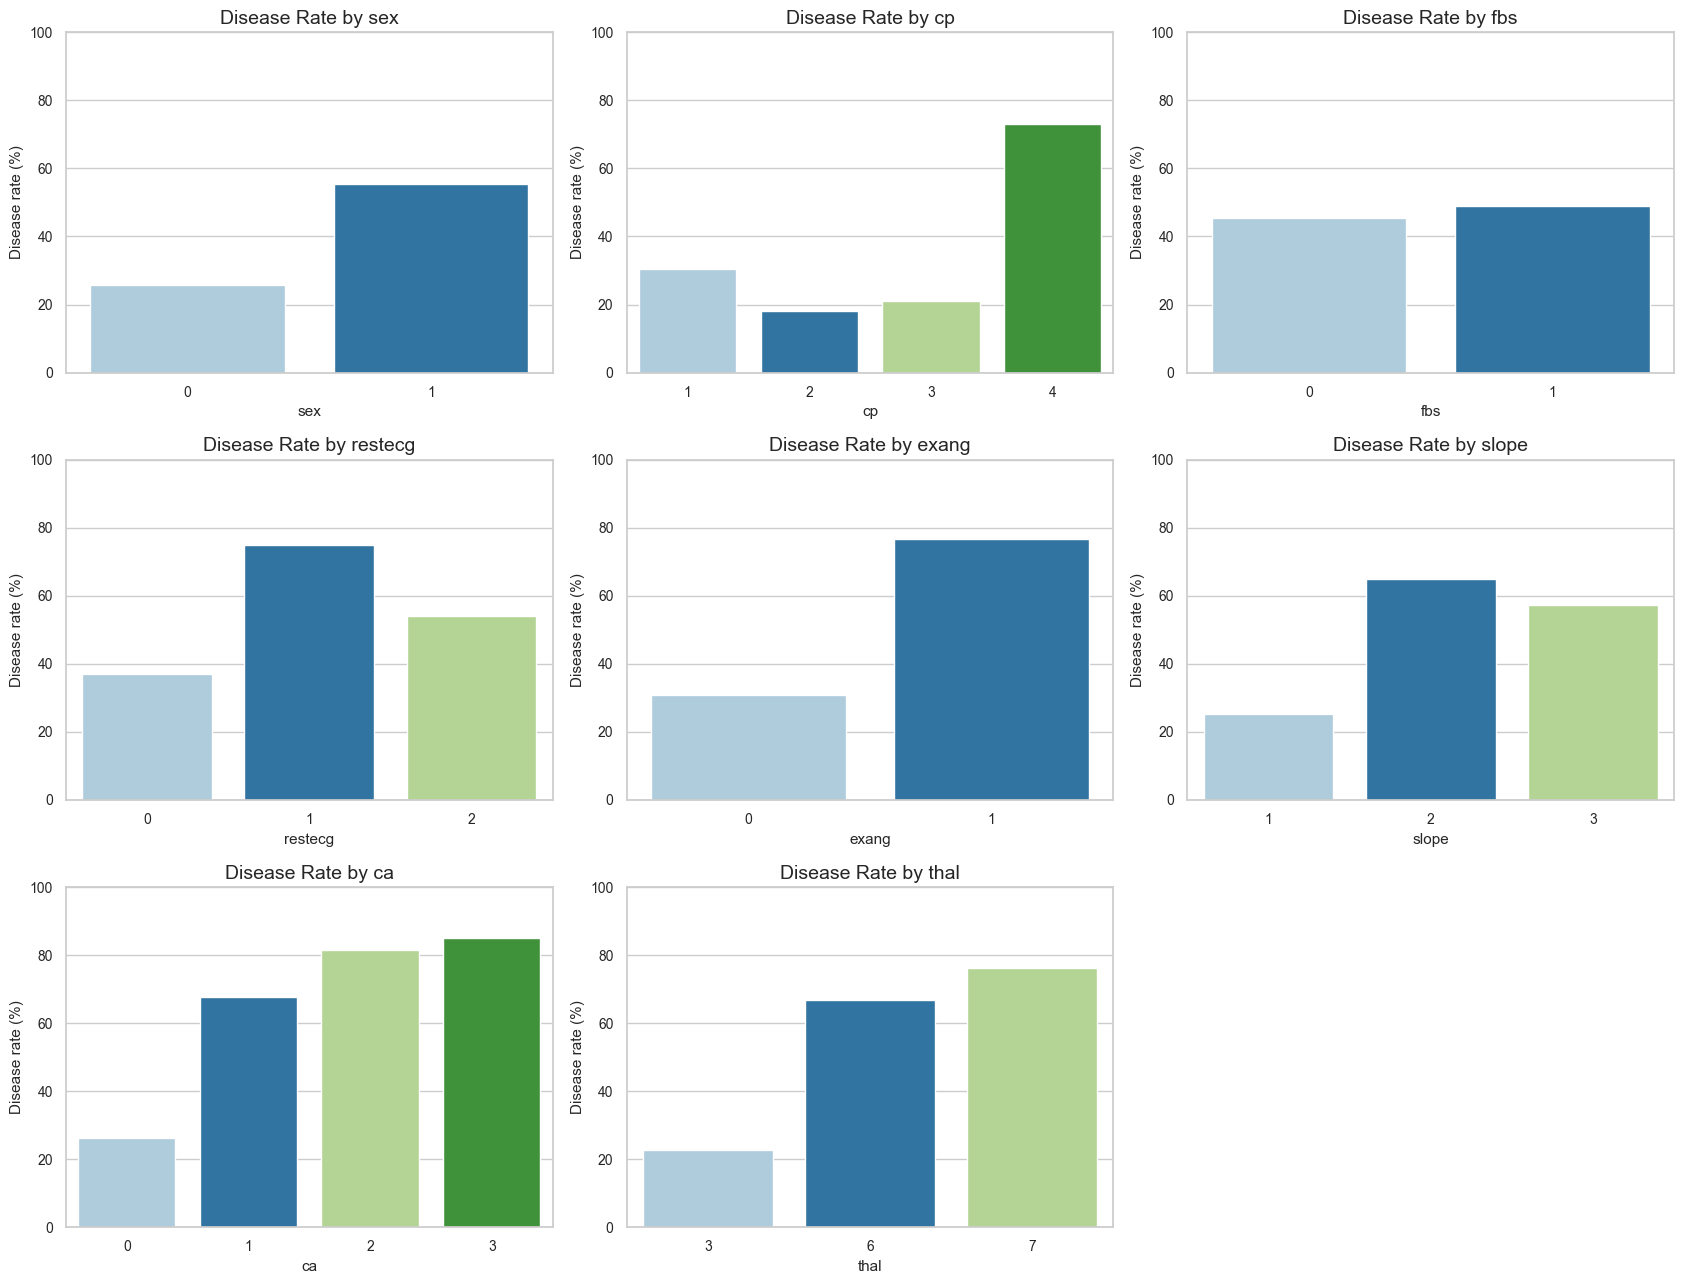

In [ ]:
# Visualize disease rate to find risk high/low
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    plot_data = category_target_rate.query("feature == @col")
    category_palette = CATEGORY_PALETTE[: plot_data["category"].nunique()]
    sns.barplot(data=plot_data, x="category", y="disease_rate", hue="category", palette=category_palette, legend=False, ax=ax)
    ax.set_title(f"Disease Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Disease rate (%)")
    ax.set_ylim(0, 100)

for ax in axes[len(categorical_features):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_disease_rate.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Correlation Analysis

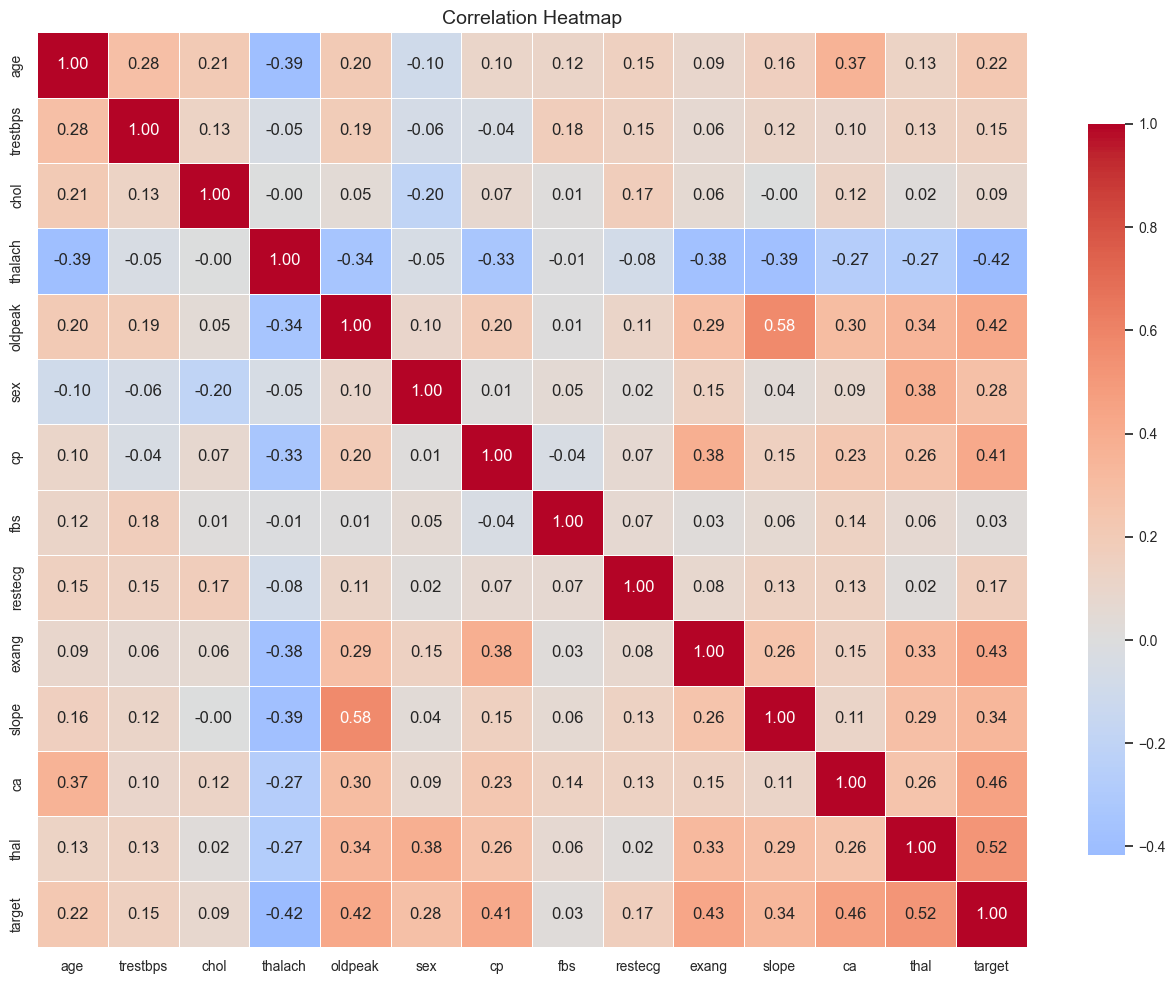

In [ ]:
# Calculate correlation
corr_columns = numeric_features + categorical_features + ["target"]
corr_matrix = df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Order feature
target_correlation = (
    corr_matrix["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_target")
)
target_correlation["abs_correlation"] = target_correlation["correlation_with_target"].abs()

display(target_correlation.round(3))
target_correlation.to_csv(TABLES_DIR / "target_correlation.csv")

,correlation_with_target,abs_correlation
thal,0.522,0.522
ca,0.460,0.460
exang,0.432,0.432
oldpeak,0.425,0.425
thalach,-0.417,0.417
cp,0.414,0.414
slope,0.339,0.339
sex,0.277,0.277
age,0.223,0.223
restecg,0.169,0.169


## 8. EDA Summary

**Evalute:**

- Dataset có 303 records và 14 cột ban đầu; không có duplicate records.
- Missing values chỉ xuất hiện ở `ca` và `thal`, số lượng rất nhỏ, đã được impute bằng mode vì đây là biến phân loại.
- Sau khi nhị phân hóa target, dữ liệu tương đối cân bằng: nhóm không bệnh khoảng 54%, nhóm có bệnh khoảng 46%.
- Các biến có tín hiệu rõ với target gồm `thal`, `ca`, `exang`, `oldpeak`, `thalach`, `cp`.
- `chol`, `trestbps` và `oldpeak` có một số giá trị cao, nên cần scaling/robustness check ở bước modeling.
- Khi modeling, nên one-hot encode các biến phân loại như `cp`, `restecg`, `slope`, `ca`, `thal` thay vì xem chúng là biến số liên tục.


In [ ]:
# Write file markdown for summary reports or copy
summary_lines = [
    "# EDA Summary - Heart Disease Dataset",
    "",
    "## Dataset Overview",
    f"- Number of rows: {df.shape[0]}",
    f"- Number of original columns: {len(columns)}",
    f"- Duplicate rows: {duplicate_count}",
    "",
    "## Missing Values",
    "- `ca`: 4 missing values, imputed with mode.",
    "- `thal`: 2 missing values, imputed with mode.",
    "",
    "## Target Distribution",
    target_summary.to_markdown(index=False),
    "",
    "## Strongest Correlations With Binary Target",
    target_correlation.head(8).round(3).to_markdown(),
    "",
    "## Modeling Notes",
    "- Use binary target: `0 = no disease`, `1 = disease`.",
    "- Apply one-hot encoding to categorical features.",
    "- Scale numerical features for distance-based or regularized models.",
    "- Evaluate with accuracy, precision, recall, F1-score and ROC-AUC because this is a medical classification problem.",
]
summary_text = "\n".join(summary_lines) + "\n"

summary_path = REPORTS_DIR / "eda_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print(f"Saved EDA summary to: {summary_path}")

Saved EDA summary to: /home/dthanh/Documents/Personal_Doc/ThS/HP2/PPNCKH/Project/heart-disease-classification/reports/eda_summary.md
